In [1]:
import os
base = "/kaggle/input/datasets/urbikn/sroie-datasetv2"  # adjust to actual path after adding dataset
for root, dirs, files in os.walk(base):
    for f in files[:3]:  # preview first 3 files per folder
        print(os.path.join(root, f))

/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/layoutlm-base-uncased/config.json
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/layoutlm-base-uncased/training_args.bin
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/layoutlm-base-uncased/tokenizer_config.json
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/box/X51006008082.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/box/X51008099090.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/box/X51005806692.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/entities/X51006008082.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/entities/X51008099090.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/entities/X51005806692.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/img/X51005719889.jpg
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/img/X51005447859.jpg
/kaggle/input/datasets/urbikn/sroie-dataset

In [2]:
# Cell 2 — peek inside a box file (bounding boxes + transcription)
box_path = "/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/train/box/X51005705760.txt"
with open(box_path) as f:
    for line in f.readlines()[:5]:
        print(line.strip())

216,255,565,255,565,351,216,351,MYDIN
152,355,623,355,623,411,152,411,TRI SHAAS SDN BHD (728515-M)
233,402,556,402,556,451,233,451,MYDIN MART SRI MUDA
75,439,689,439,689,495,75,495,4-20, JALAN RIA 25/62 TAMAN SRI MUDA
88,483,683,483,683,534,88,534,SEKSYEN 25, 40400 SHAH ALAM SELANGOR


In [3]:
# Cell 3 — peek inside an entities file (key fields: company, date, total, address)
ent_path = "/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/train/entities/X51005705760.txt"
with open(ent_path) as f:
    print(f.read())

{
    "company": "TRI SHAAS SDN BHD",
    "date": "10/08/2017",
    "address": "4-20, JALAN RIA 25/62 TAMAN SRI MUDA SEKSYEN 25, 40400 SHAH ALAM SELANGOR",
    "total": "21.40"
}


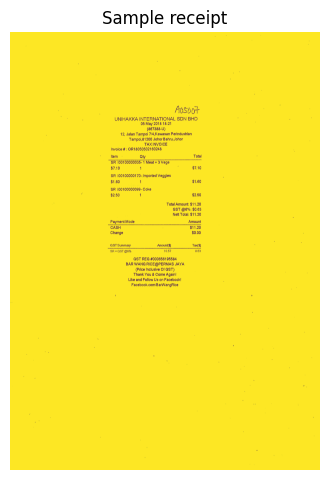

Size: (4961, 7016)


In [4]:
# Cell 4 — display the corresponding receipt image
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/train/img/X51007231344.jpg"
img = Image.open(img_path)
plt.figure(figsize=(4, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Sample receipt")
plt.show()
print(f"Size: {img.size}")

In [5]:
# Cell 5 — full annotation parser + crop pipeline
import os
import json
from PIL import Image
import matplotlib.pyplot as plt

BASE = "/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019"

def parse_box_file(box_path):
    """Parse a SROIE box file into list of (bbox, text) tuples.
       bbox = (x_min, y_min, x_max, y_max) as integers.
    """
    samples = []
    with open(box_path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(",", 8)   # split on first 8 commas only
            if len(parts) < 9:
                continue
            coords = list(map(int, parts[:8]))
            text   = parts[8].strip()
            if not text:
                continue
            xs = coords[0::2]            # x1, x2, x3, x4
            ys = coords[1::2]            # y1, y2, y3, y4
            bbox = (min(xs), min(ys), max(xs), max(ys))
            samples.append((bbox, text))
    return samples

def crop_text_lines(split="train", max_receipts=5):
    """
    For each receipt in the split:
      - open the image
      - parse the box file
      - crop each text-line bbox
      - return list of {"image": PIL crop, "text": str, "receipt_id": str}
    """
    img_dir = os.path.join(BASE, split, "img")
    box_dir = os.path.join(BASE, split, "box")
    
    samples = []
    receipt_ids = sorted([f[:-4] for f in os.listdir(img_dir) if f.endswith(".jpg")])
    
    for rid in receipt_ids[:max_receipts]:
        img_path = os.path.join(img_dir, rid + ".jpg")
        box_path = os.path.join(box_dir, rid + ".txt")
        if not os.path.exists(box_path):
            continue
        img   = Image.open(img_path).convert("RGB")
        boxes = parse_box_file(box_path)
        for bbox, text in boxes:
            crop = img.crop(bbox)
            if crop.width < 10 or crop.height < 10:   # skip degenerate crops
                continue
            samples.append({"image": crop, "text": text, "receipt_id": rid})
    return samples

# --- test it on 5 receipts ---
samples = crop_text_lines(split="train", max_receipts=5)
print(f"Total crops: {len(samples)}")
print(f"Example text labels: {[s['text'] for s in samples[:8]]}")

Total crops: 267
Example text labels: ['TAN WOON YANN', 'BOOK TA .K(TAMAN DAYA) SDN BND', '789417-W', 'NO.53 55,57 & 59, JALAN SAGU 18,', 'TAMAN DAYA,', '81100 JOHOR BAHRU,', 'JOHOR.', 'DOCUMENT NO : TD01167104']


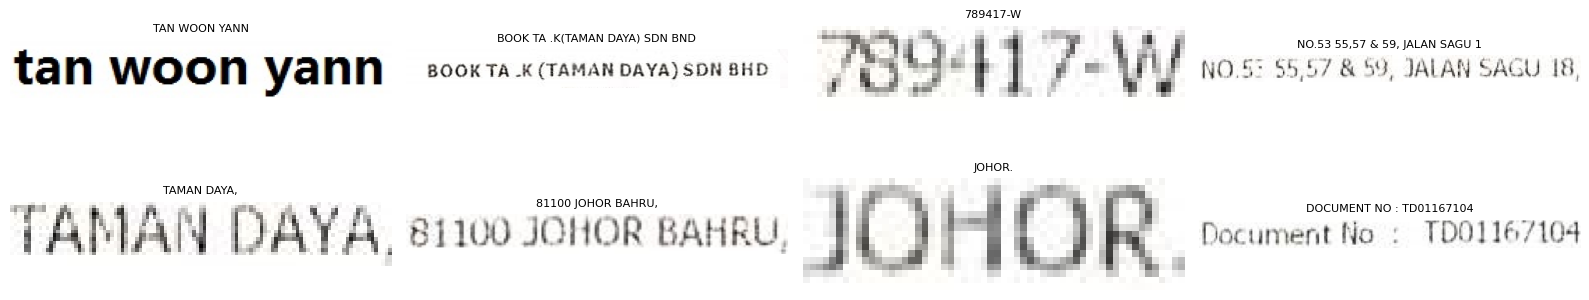

In [6]:
# Cell 6 — visual sanity check: show 8 crops with their labels
fig, axes = plt.subplots(2, 4, figsize=(16, 4))
for ax, s in zip(axes.flat, samples[:8]):
    ax.imshow(s["image"])
    ax.set_title(s["text"][:30], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
# Cell 7 — load ALL train + test crops
train_samples = crop_text_lines(split="train", max_receipts=9999)
test_samples  = crop_text_lines(split="test",  max_receipts=9999)

print(f"Train crops : {len(train_samples)}")
print(f"Test crops  : {len(test_samples)}")

Train crops : 33539
Test crops  : 18645


In [8]:
# Cell 8 — split train into train/val (90/10)
import random
random.seed(42)
random.shuffle(train_samples)

split_idx   = int(len(train_samples) * 0.9)
val_samples = train_samples[split_idx:]
train_samples = train_samples[:split_idx]

print(f"Final train : {len(train_samples)}")
print(f"Final val   : {len(val_samples)}")
print(f"Final test  : {len(test_samples)}")

Final train : 30185
Final val   : 3354
Final test  : 18645


In [9]:
# Cell 9 — save crops to disk instead of preprocessing all in RAM
import os
from PIL import Image

SAVE_DIR = "/kaggle/working/crops"
os.makedirs(f"{SAVE_DIR}/train", exist_ok=True)
os.makedirs(f"{SAVE_DIR}/val",   exist_ok=True)
os.makedirs(f"{SAVE_DIR}/test",  exist_ok=True)

def save_split(samples, split):
    manifest = []   # list of {"img_path": ..., "text": ...}
    for i, s in enumerate(samples):
        img_path = f"{SAVE_DIR}/{split}/{i}.jpg"
        s["image"].convert("RGB").save(img_path, quality=85)
        manifest.append({"img_path": img_path, "text": s["text"]})
    return manifest

print("Saving train...")
train_manifest = save_split(train_samples, "train")
print("Saving val...")
val_manifest   = save_split(val_samples,   "val")
print("Saving test...")
test_manifest  = save_split(test_samples,  "test")

print(f"Done. Train:{len(train_manifest)} Val:{len(val_manifest)} Test:{len(test_manifest)}")

Saving train...
Saving val...
Saving test...
Done. Train:30185 Val:3354 Test:18645


In [10]:
# Cell 10 — lightweight Dataset that loads + processes one image at a time
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import TrOCRProcessor
from PIL import Image

CHECKPOINT = "microsoft/trocr-base-printed"
processor  = TrOCRProcessor.from_pretrained(CHECKPOINT)

class SROIEDataset(TorchDataset):
    def __init__(self, manifest):
        self.manifest = manifest

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        item = self.manifest[idx]
        img  = Image.open(item["img_path"]).convert("RGB")
        pixel_values = processor(images=img, return_tensors="pt").pixel_values.squeeze()
        labels = processor.tokenizer(
            item["text"],
            padding="max_length",
            max_length=64,
            truncation=True
        ).input_ids
        labels = [l if l != processor.tokenizer.pad_token_id else -100 for l in labels]
        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(labels)
        }

train_ds = SROIEDataset(train_manifest)
val_ds   = SROIEDataset(val_manifest)
test_ds  = SROIEDataset(test_manifest)

# quick sanity check — load one sample
sample = train_ds[0]
print("pixel_values shape:", sample["pixel_values"].shape)
print("labels shape      :", sample["labels"].shape)
print("decoded label     :", processor.tokenizer.decode(
    [l for l in sample["labels"].tolist() if l != -100]
))

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pixel_values shape: torch.Size([3, 384, 384])
labels shape      : torch.Size([64])
decoded label     : <s>*S</s>


In [11]:
# Cell 11 — verify a few samples to confirm labels are healthy
for i in [0, 1, 2, 10, 50, 200]:
    s = train_ds[i]
    decoded = processor.tokenizer.decode(
        [l for l in s["labels"].tolist() if l != -100]
    )
    print(f"[{i:>4}] {decoded}")

[   0] <s>*S</s>
[   1] <s>9.72</s>
[   2] <s>QTY</s>
[  10] <s>TOTAL (GST INCL)</s>
[  50] <s>0.46</s>
[ 200] <s>0</s>


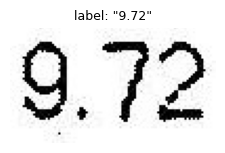

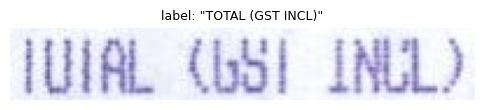

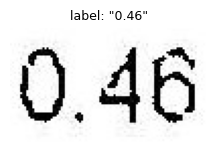

In [12]:
# Cell 12 — show the image + label side by side for index 1 and 10
import matplotlib.pyplot as plt
from PIL import Image

for idx in [1, 10, 50]:
    item = train_manifest[idx]
    img  = Image.open(item["img_path"])
    plt.figure(figsize=(6, 1.5))
    plt.imshow(img)
    plt.title(f'label: "{item["text"]}"', fontsize=9)
    plt.axis("off")
    plt.show()

In [13]:
# Cell 13 — load TrOCR model
from transformers import VisionEncoderDecoderModel
import torch

CKPT  = "microsoft/trocr-base-printed"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = VisionEncoderDecoderModel.from_pretrained(CKPT)

# required config for TrOCR decoding
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

model.to(device)
print("Model loaded.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda


model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.
Parameters: 333,921,792


In [14]:
# Cell 14 — DataLoader (subsampled to fit Kaggle session)
from torch.utils.data import DataLoader, Subset
import random

random.seed(42)

# subsample train to 10k, keep full val and test
train_indices = random.sample(range(len(train_ds)), 10_000)
train_subset  = Subset(train_ds, train_indices)

train_loader = DataLoader(train_subset, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,       batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples : {len(train_subset)}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train samples : 10000
Train batches : 1250
Val batches   : 420


In [15]:
# Cell 15 — optimizer + scheduler
from transformers import get_linear_schedule_with_warmup

EPOCHS    = 8
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * 0.1)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")

Total steps  : 10000
Warmup steps : 1000


In [16]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 31.9 MB/s eta 0:00:00


In [17]:
# Cell 16 — CER metric
from jiwer import cer, wer

def evaluate(model, loader, split="val"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            pixel_values = batch["pixel_values"].to(device)
            generated = model.generate(pixel_values, max_new_tokens=64)
            preds  = processor.tokenizer.batch_decode(generated, skip_special_tokens=True)
            labels = processor.tokenizer.batch_decode(
                [[l for l in lab.tolist() if l != -100] for lab in batch["labels"]],
                skip_special_tokens=True
            )
            all_preds  += preds
            all_labels += labels
    c = cer(all_labels, all_preds)
    w = wer(all_labels, all_preds)
    print(f"[{split}] CER: {c:.4f}  WER: {w:.4f}")
    return c, w

In [18]:
# Cell 17 — training loop
import time
import json

best_cer   = float("inf")
train_losses = []
val_cers     = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0
    t0 = time.time()

    for step, batch in enumerate(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss    = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

        if step % 200 == 0:
            avg = epoch_loss / (step + 1)
            elapsed = time.time() - t0
            print(f"  Epoch {epoch} | step {step}/{len(train_loader)} | loss {avg:.4f} | {elapsed:.0f}s")

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"\nEpoch {epoch} done — avg loss: {avg_loss:.4f}")

    # evaluate on val
    val_cer, val_wer = evaluate(model, val_loader, split="val")
    val_cers.append(val_cer)

    # save best model
    if val_cer < best_cer:
        best_cer = val_cer
        model.save_pretrained("/kaggle/working/best_model")
        processor.save_pretrained("/kaggle/working/best_model")
        print(f"  ✓ Best model saved (CER {best_cer:.4f})\n")

with open("/kaggle/working/training_history.json", "w") as f:
    json.dump({"train_losses": train_losses, "val_cers": val_cers}, f)
print("History saved.")

  Epoch 1 | step 0/1250 | loss 8.3768 | 3s
  Epoch 1 | step 200/1250 | loss 1.5000 | 281s
  Epoch 1 | step 400/1250 | loss 0.8164 | 564s
  Epoch 1 | step 600/1250 | loss 0.6504 | 847s
  Epoch 1 | step 800/1250 | loss 0.6181 | 1129s
  Epoch 1 | step 1000/1250 | loss 0.6268 | 1412s
  Epoch 1 | step 1200/1250 | loss 0.6598 | 1695s

Epoch 1 done — avg loss: 0.6652
[val] CER: 0.3684  WER: 0.4583


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (CER 0.3684)

  Epoch 2 | step 0/1250 | loss 0.6101 | 2s
  Epoch 2 | step 200/1250 | loss 0.6831 | 284s
  Epoch 2 | step 400/1250 | loss 0.6557 | 567s
  Epoch 2 | step 600/1250 | loss 0.6340 | 850s
  Epoch 2 | step 800/1250 | loss 0.6135 | 1132s
  Epoch 2 | step 1000/1250 | loss 0.5874 | 1415s
  Epoch 2 | step 1200/1250 | loss 0.5766 | 1698s

Epoch 2 done — avg loss: 0.5772
[val] CER: 0.2315  WER: 0.3537


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (CER 0.2315)

  Epoch 3 | step 0/1250 | loss 0.8671 | 2s
  Epoch 3 | step 200/1250 | loss 0.3964 | 285s
  Epoch 3 | step 400/1250 | loss 0.3918 | 567s
  Epoch 3 | step 600/1250 | loss 0.4044 | 850s
  Epoch 3 | step 800/1250 | loss 0.3877 | 1133s
  Epoch 3 | step 1000/1250 | loss 0.3787 | 1416s
  Epoch 3 | step 1200/1250 | loss 0.3751 | 1699s

Epoch 3 done — avg loss: 0.3746
[val] CER: 0.1136  WER: 0.2383


...

  ✓ Best model saved (CER 0.0721)

  Epoch 5 | step 0/1250 | loss 0.2048 | 2s
  Epoch 5 | step 200/1250 | loss 0.1328 | 284s
  Epoch 5 | step 400/1250 | loss 0.1380 | 567s
  Epoch 5 | step 600/1250 | loss 0.1376 | 850s
  Epoch 5 | step 800/1250 | loss 0.1366 | 1133s
  Epoch 5 | step 1000/1250 | loss 0.1316 | 1416s
  Epoch 5 | step 1200/1250 | loss 0.1278 | 1699s

Epoch 5 done — avg loss: 0.1274
[val] CER: 0.0722  WER: 0.1443
  Epoch 6 | step 0/1250 | loss 0.0897 | 2s
  Epoch 6 | step 200/1250 | loss 0.0899 | 285s
  Epoch 6 | step 400/1250 | loss 0.0924 | 568s
  Epoch 6 | step 600/1250 | loss 0.0899 | 851s
  Epoch 6 | step 800/1250 | loss 0.0888 | 1135s
  Epoch 6 | step 1000/1250 | loss 0.0844 | 1417s
  Epoch 6 | step 1200/1250 | loss 0.0824 | 1700s

Epoch 6 done — avg loss: 0.0815
[val] CER: 0.0462  WER: 0.1244


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (CER 0.0462)

  Epoch 7 | step 0/1250 | loss 0.0029 | 2s
  Epoch 7 | step 200/1250 | loss 0.0466 | 285s
  Epoch 7 | step 400/1250 | loss 0.0406 | 567s
  Epoch 7 | step 600/1250 | loss 0.0366 | 850s
  Epoch 7 | step 800/1250 | loss 0.0375 | 1133s
  Epoch 7 | step 1000/1250 | loss 0.0379 | 1416s
  Epoch 7 | step 1200/1250 | loss 0.0370 | 1699s

Epoch 7 done — avg loss: 0.0364
[val] CER: 0.0245  WER: 0.0902


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved (CER 0.0245)

  Epoch 8 | step 0/1250 | loss 0.0051 | 2s
  Epoch 8 | step 200/1250 | loss 0.0145 | 285s
  Epoch 8 | step 400/1250 | loss 0.0195 | 567s
  Epoch 8 | step 600/1250 | loss 0.0181 | 850s
  Epoch 8 | step 800/1250 | loss 0.0173 | 1133s
  Epoch 8 | step 1000/1250 | loss 0.0171 | 1416s
  Epoch 8 | step 1200/1250 | loss 0.0168 | 1698s

Epoch 8 done — avg loss: 0.0168
[val] CER: 0.0250  WER: 0.0917
History saved.
